# Importing Libraries

In [1]:
# Core Data Manipulation
import pandas as pd

# Machine Learning & Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Data Visualization
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Geospatial Analysis
import geopandas as gpd

# Loading DF

In [2]:
pre_norm_df_final = pd.read_csv('..\\Data\\display_rdy_ZIP_4.csv', low_memory=False)
norm_df = pd.read_csv('..\\Data\\norm_ZIP_5.csv', low_memory=False)
nyc_map = gpd.read_file("..\\Data\\Modified Zip Code Tabulation Areas (MODZCTA).geojson")


# Clustering KMEANS

In [3]:
# Print clustering output
def output(labels):
    labels = pd.Series(labels)
    print("The labels:\n", labels)
    print("===================")
    print("Value Counts:\n", labels.value_counts())


In [4]:
# Drop incident zip column
Features = norm_df.drop("Incident_Zip", axis=1)

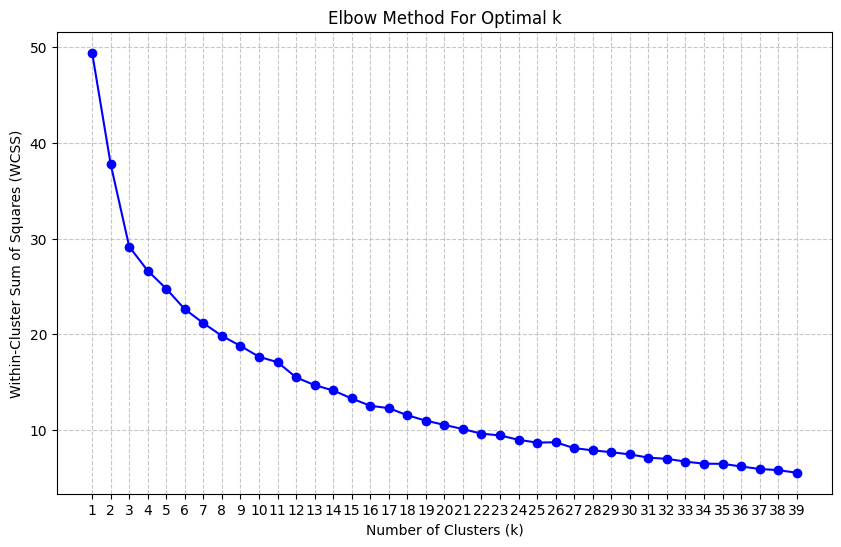

In [5]:
# Calculate WCSS (Inertia) for different values of k
wcss = []
k_range = range(1, 40) # Testing k=1 through k=40

for k in k_range:
    # random_state ensures reproducible results
    # n_init=10 suppresses future warnings in scikit-learn
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(Features)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='-', color='b')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

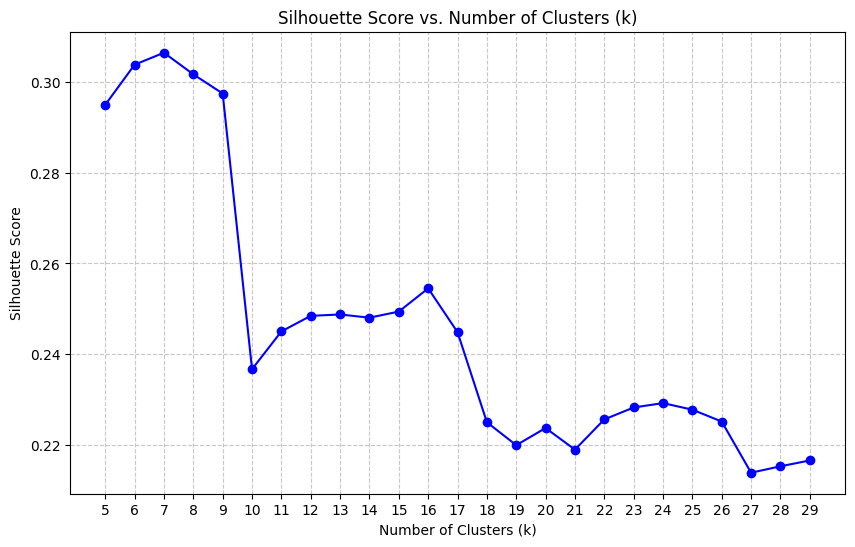

In [6]:
score_lst = []
k_range = range(5, 30) # Define the range once to keep it consistent

for k in k_range:
    # Get labels
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto").fit(Features)
    labels = pd.Series(kmeans.labels_)
    pre_norm_df_final["Cluster"] = labels

    # Calculate the Silhouette Score
    score = silhouette_score(Features, labels)
    score_lst.append(score)

# Create the x-axis list (number of clusters)
k_lst = list(k_range)    

# --- Make the plot ---
plt.figure(figsize=(10, 6)) # Set the figure size
plt.plot(k_lst, score_lst, marker='o', linestyle='-', color='b') # Added points 'o' for visibility

# Add labels and title
plt.title('Silhouette Score vs. Number of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')

# Formatting to make it look nice
plt.xticks(k_lst) # Shows every 'k' value on the x-axis
plt.grid(True, linestyle='--', alpha=0.7) # Adds a subtle grid

# Display the plot
plt.show()

We chose 7 clusters according to both graphs.

In [7]:
kmeans = KMeans(n_clusters=7,random_state=42, n_init="auto").fit(Features)
labels = pd.Series(kmeans.labels_)
pre_norm_df_final["Cluster"] = labels
output(labels)

The labels:
 0      2
1      2
2      1
3      2
4      4
      ..
234    3
235    3
236    4
237    3
238    3
Length: 239, dtype: int32
Value Counts:
 3    96
1    63
2    33
4    19
6    15
0    11
5     2
Name: count, dtype: int64


In [8]:
vc = labels.value_counts()
vc

3    96
1    63
2    33
4    19
6    15
0    11
5     2
Name: count, dtype: int64

In [9]:
# Define the tiny outlier clusters we want to push to the end
outlier_clusters = singleton_labels = vc[vc == 1].index.tolist()

# Get a list of all current clusters in the dataframe, sorted numerically
current_clusters = sorted(pre_norm_df_final['Cluster'].dropna().unique())

# Separate the "main" clusters from the "outlier" clusters
main_clusters = [c for c in current_clusters if c not in outlier_clusters]
outliers_present = [c for c in outlier_clusters if c in current_clusters]

# Create a new ordered list: Main clusters first, followed by outliers at the end
new_cluster_order = main_clusters + outliers_present

# Create a mapping dictionary {old_id: new_id}
# This automatically assigns 0, 1, 2... etc.
# The main clusters will become 0 to 10, and the outliers will become 11, 12, 13, 14.
cluster_mapping = {old_id: new_id for new_id, old_id in enumerate(new_cluster_order)}

# Let's print the mapping so you can verify it worked exactly as you wanted
print("Here is how the clusters are being renumbered:")
for old, new in cluster_mapping.items():
    print(f"Old Cluster {old} --> New Cluster {new}")

# Apply the mapping to overwrite the old numbers
pre_norm_df_final['Cluster'] = pre_norm_df_final['Cluster'].map(cluster_mapping)

Here is how the clusters are being renumbered:
Old Cluster 0 --> New Cluster 0
Old Cluster 1 --> New Cluster 1
Old Cluster 2 --> New Cluster 2
Old Cluster 3 --> New Cluster 3
Old Cluster 4 --> New Cluster 4
Old Cluster 5 --> New Cluster 5
Old Cluster 6 --> New Cluster 6


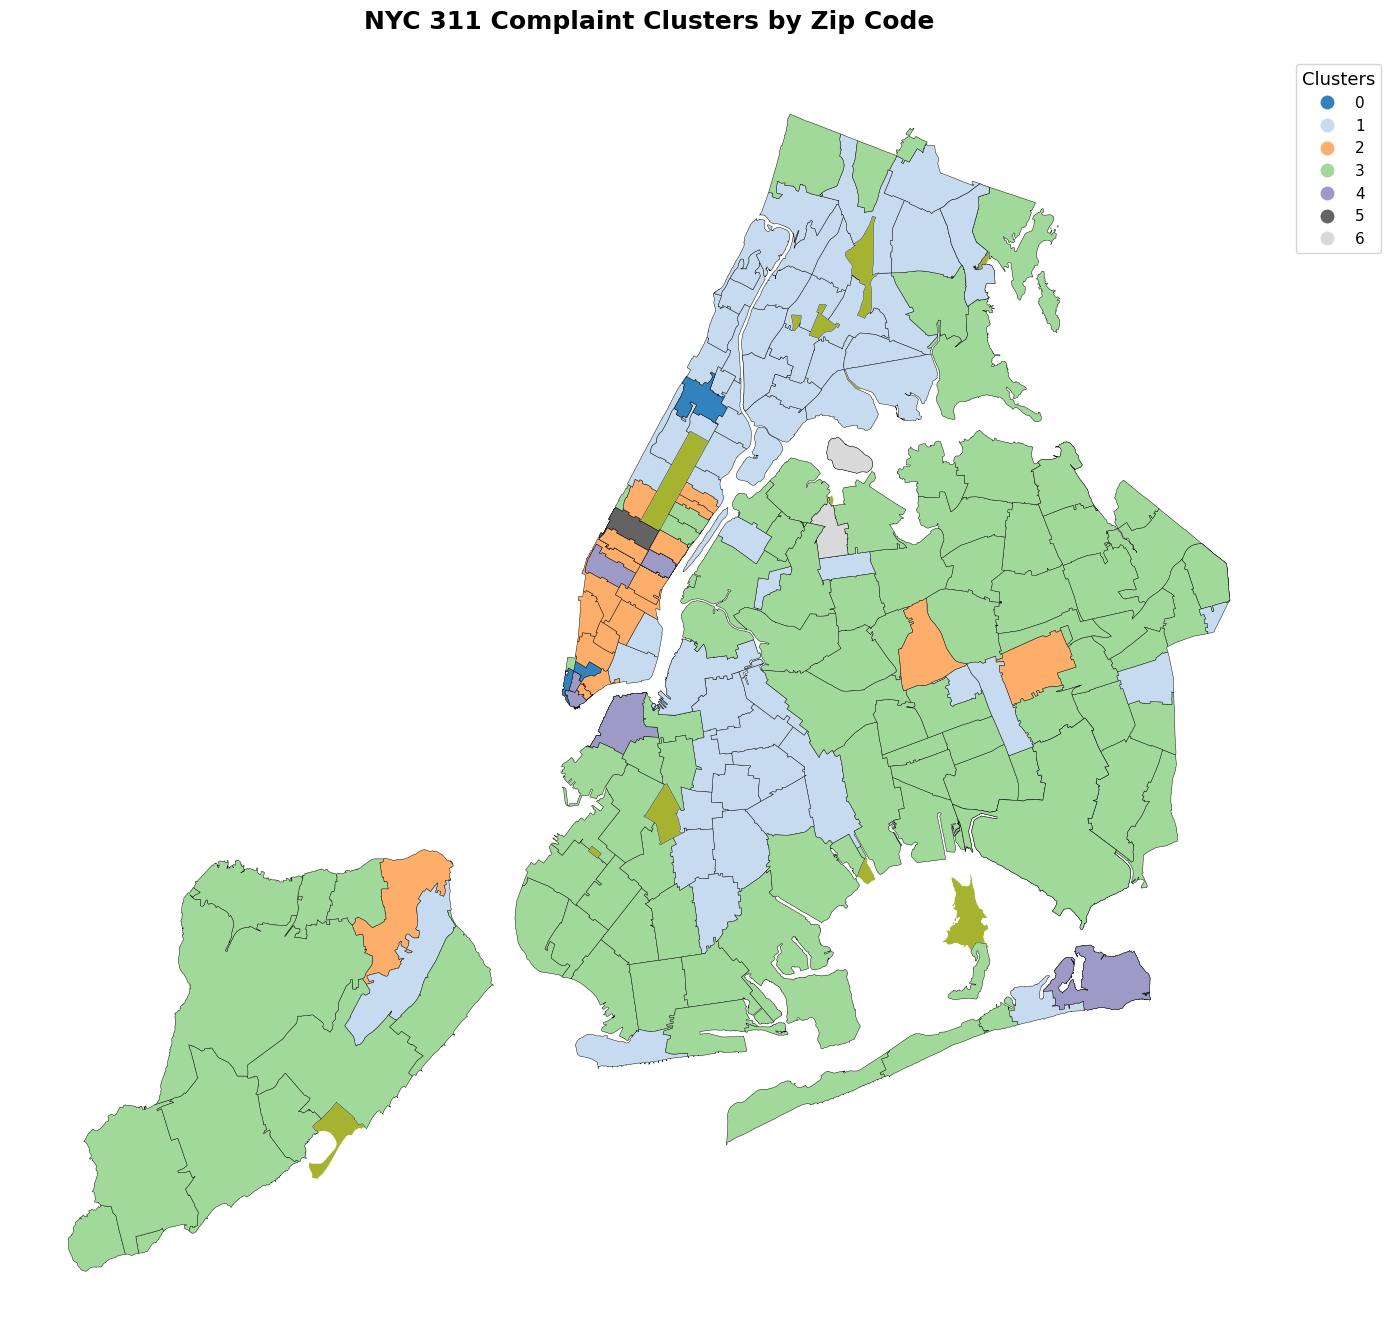

In [10]:
pree_norm_df_final = pre_norm_df_final.reset_index()

# Clean up zip codes to remove decimals and ensure standard format
pree_norm_df_final['Incident_Zip'] = (
    pree_norm_df_final['Incident_Zip']
    .astype(str)
    .str.split('.')
    .str[0]
    .str.zfill(5)
)
nyc_map['modzcta'] = nyc_map['modzcta'].astype(str).str.strip()

# This maps point/vanity zips, airports, splits, and former "trash" zips to their parent polygons (We used an LLM to categorize the zips)
zip_crosswalk = {
    # Midtown Manhattan Vanity Zips
    '10118': '10001', '10119': '10001', '10120': '10001', '10121': '10001', 
    '10122': '10001', '10123': '10001', '10151': '10022', '10152': '10022', 
    '10153': '10022', '10154': '10022', '10155': '10022', '10165': '10017', 
    '10166': '10017', '10167': '10017', '10168': '10017', '10169': '10017', 
    '10170': '10017', '10171': '10017', '10172': '10017', '10173': '10017', 
    '10174': '10017', '10020': '10036', '10041': '10004', '10045': '10005', 
    '10048': '10007', '10055': '10022', '10080': '10007', '10103': '10019', 
    '10105': '10019', '10106': '10019', '10107': '10019', '10110': '10036', 
    '10111': '10036', '10112': '10036', '10115': '10027', '10158': '10017', 
    '10162': '10021', '10175': '10017', '10176': '10017', '10177': '10017', 
    '10178': '10017', '10179': '10017',
    
    # Financial District / Downtown
    '10271': '10005', '10278': '10007', '10279': '10007', '10281': '10280',
    
    # Brooklyn Zips & Splits
    '11249': '11211', '11241': '11201', '11242': '11201', '11251': '11201',
    
    # Queens / Airports / Special Facilities
    '11359': '11360', # Fort Totten
    '11371': '11370', # LaGuardia Airport
    '11430': '11434', # JFK Airport
    '11695': '11691', # Far Rockaway
    '11005': '11004', # Glen Oaks border

    # --- FORMER TRASH ZIPS INCORPORATED HERE ---
    
    # Bordering Nassau & Westchester Counties (Mapped to closest NYC neighborhood)
    '10803': '10475', # Pelham Manor -> mapped to Bronx border
    '11001': '11004', # Floral Park (Nassau) -> mapped to Floral Park (Queens)
    '11021': '11363', # Great Neck -> mapped to Little Neck
    '11040': '11004', # New Hyde Park -> mapped to Floral Park (Queens)
    '11096': '11691', # Inwood (Nassau) -> mapped to Far Rockaway
    '11803': '11426', # Plainview -> mapped to Bellerose (Eastern Queens edge)

    # NYC Vanity, Parks, and Error Defaults
    '00083': '10024', # Central Park -> mapped to Upper West Side
    '10000': '10001', # Generic NYC Error -> mapped to Midtown
    '10400': '10451', # Generic Bronx Error -> mapped to South Bronx

}

# Apply crosswalk maps
pree_norm_df_final['Incident_Zip'] = pree_norm_df_final['Incident_Zip'].replace(zip_crosswalk)


# Merge the geographic polygons with the clustering labels
mapped_clusters = nyc_map.merge(
    pree_norm_df_final, 
    left_on='modzcta', 
    right_on='Incident_Zip', 
    how='inner'
)

# Plot the Choropleth Map
fig, ax = plt.subplots(1, 1, figsize=(14, 14))

# Plot a light grey base map of ALL NYC zip codes behind the data for context
nyc_map.plot(ax=ax, color="#a6b330", edgecolor='white', linewidth=0.5)

# Plot the specific clusters
mapped_clusters.plot(
    column='Cluster', 
    ax=ax, 
    categorical=True, 
    legend=True,
    cmap='tab20c',     
    edgecolor='black',
    linewidth=0.3,
    legend_kwds={
        'loc': 'upper left', 
        'bbox_to_anchor': (1, 1), 
        'title': "Clusters", 
        'fontsize': 11,
        'title_fontsize': 13
    }
)

plt.title('NYC 311 Complaint Clusters by Zip Code', fontsize=18, fontweight='bold', pad=20)
plt.axis('off') 
plt.tight_layout()
plt.show()

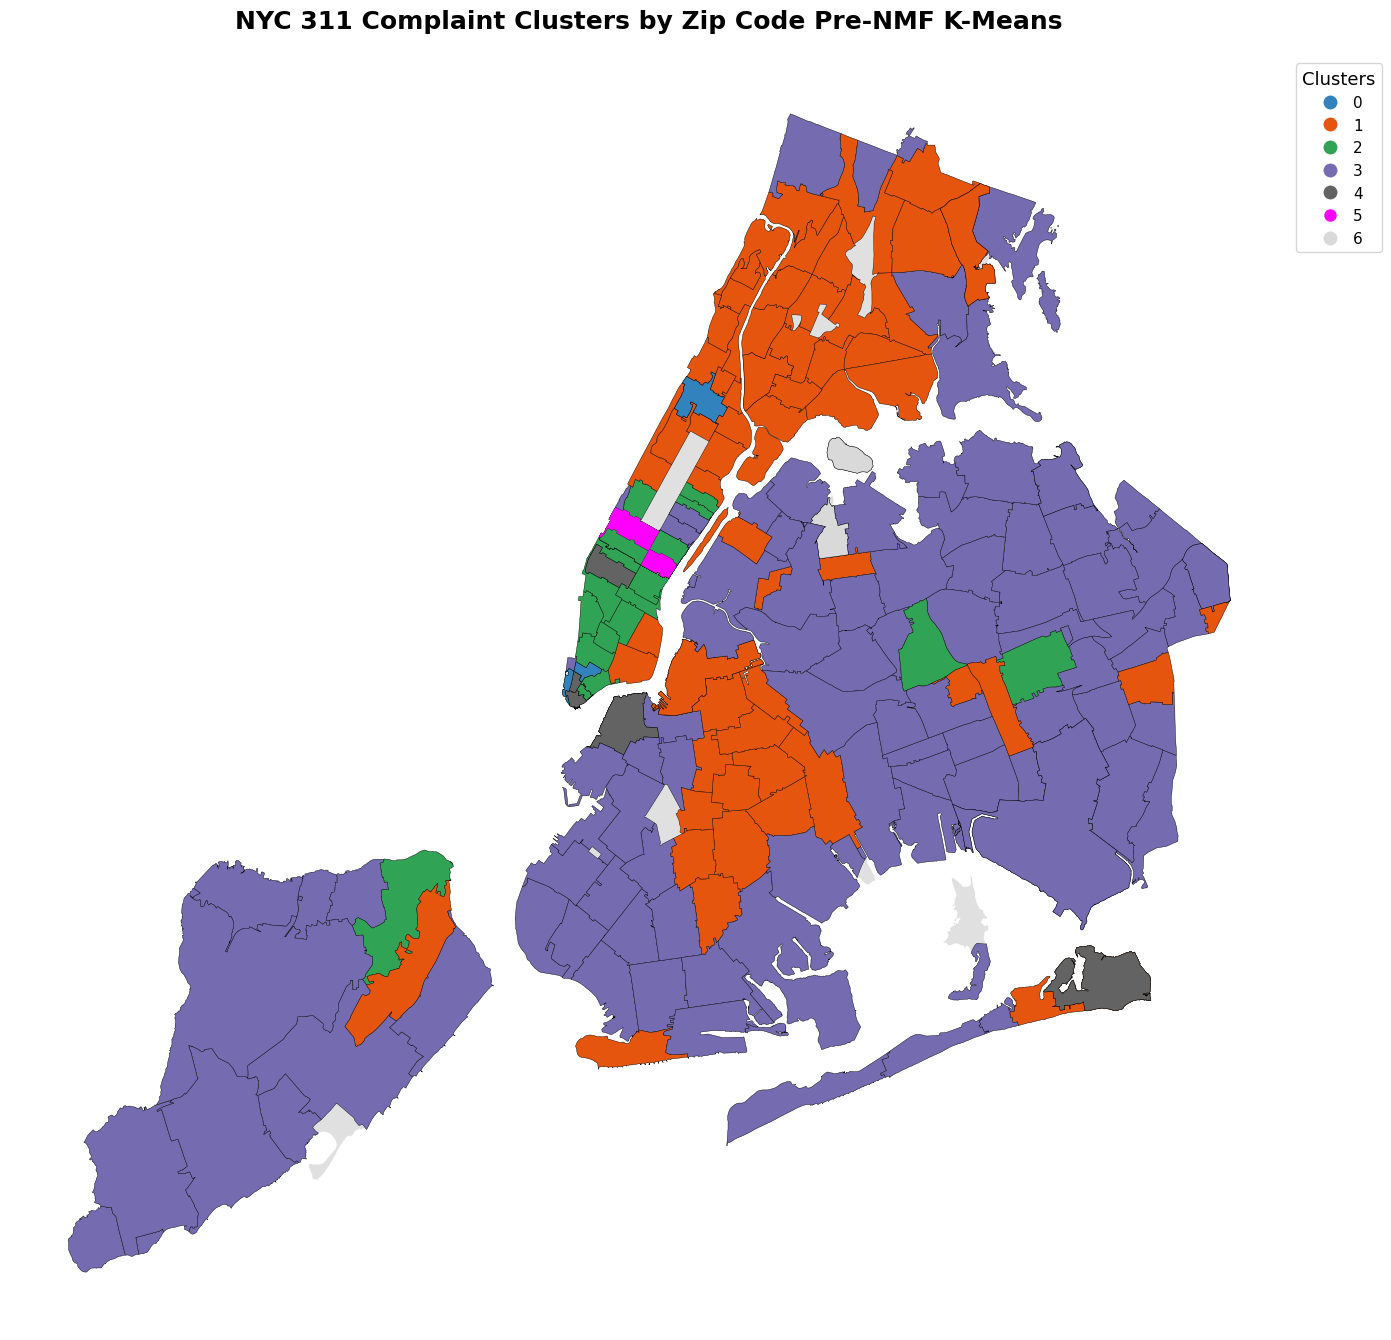

In [11]:

# Make the outliers in Neon colors so we could see them.
pree_norm_df_final = pre_norm_df_final.reset_index()

# Clean up zip codes to remove decimals and ensure standard format
pree_norm_df_final['Incident_Zip'] = (
    pree_norm_df_final['Incident_Zip']
    .astype(str)
    .str.split('.')
    .str[0]
    .str.zfill(5)
)
nyc_map['modzcta'] = nyc_map['modzcta'].astype(str).str.strip()

# Same as the code above, this maps point/vanity zips, airports, splits, and...
# ...former "trash" zips to their parent polygons (We used an LLM to categorize the zips)

zip_crosswalk = {
    # Midtown Manhattan Vanity Zips
    '10118': '10001', '10119': '10001', '10120': '10001', '10121': '10001', 
    '10122': '10001', '10123': '10001', '10151': '10022', '10152': '10022', 
    '10153': '10022', '10154': '10022', '10155': '10022', '10165': '10017', 
    '10166': '10017', '10167': '10017', '10168': '10017', '10169': '10017', 
    '10170': '10017', '10171': '10017', '10172': '10017', '10173': '10017', 
    '10174': '10017', '10020': '10036', '10041': '10004', '10045': '10005', 
    '10048': '10007', '10055': '10022', '10080': '10007', '10103': '10019', 
    '10105': '10019', '10106': '10019', '10107': '10019', '10110': '10036', 
    '10111': '10036', '10112': '10036', '10115': '10027', '10158': '10017', 
    '10162': '10021', '10175': '10017', '10176': '10017', '10177': '10017', 
    '10178': '10017', '10179': '10017',
    
    # Financial District / Downtown
    '10271': '10005', '10278': '10007', '10279': '10007', '10281': '10280',
    
    # Brooklyn Zips & Splits
    '11249': '11211', '11241': '11201', '11242': '11201', '11251': '11201',
    
    # Queens / Airports / Special Facilities
    '11359': '11360', # Fort Totten
    '11371': '11370', # LaGuardia Airport
    '11430': '11434', # JFK Airport
    '11695': '11691', # Far Rockaway
    '11005': '11004', # Glen Oaks border

    # --- FORMER TRASH ZIPS INCORPORATED HERE ---
    '10803': '10475', # Pelham Manor -> mapped to Bronx border
    '11001': '11004', # Floral Park (Nassau) -> mapped to Floral Park (Queens)
    '11021': '11363', # Great Neck -> mapped to Little Neck
    '11040': '11004', # New Hyde Park -> mapped to Floral Park (Queens)
    '11096': '11691', # Inwood (Nassau) -> mapped to Far Rockaway
    '11803': '11426', # Plainview -> mapped to Bellerose (Eastern Queens edge)

    # NYC Vanity, Parks, and Error Defaults
    '00083': '10024', # Central Park -> mapped to Upper West Side
    '10000': '10001', # Generic NYC Error -> mapped to Midtown
    '10400': '10451', # Generic Bronx Error -> mapped to South Bronx
}

# Apply crosswalk maps
pree_norm_df_final['Incident_Zip'] = pree_norm_df_final['Incident_Zip'].replace(zip_crosswalk)

# Merge the geographic polygons with the clustering labels
mapped_clusters = nyc_map.merge(
    pree_norm_df_final, 
    left_on='modzcta', 
    right_on='Incident_Zip', 
    how='inner'
)

# Detecting small clusters to highlight
small_cluster_threshold = 3 

# Count how many ZIP codes are in each cluster
cluster_sizes = mapped_clusters['Cluster'].value_counts()
small_cluster_ids = cluster_sizes[cluster_sizes <= small_cluster_threshold].index.tolist()

# Split the dataframe into "Normal" and "Small" clusters
normal_clusters_df = mapped_clusters[~mapped_clusters['Cluster'].isin(small_cluster_ids)]
small_clusters_df = mapped_clusters[mapped_clusters['Cluster'].isin(small_cluster_ids)]

# Plot the Choropleth Map with Layers & Unified Legend
fig, ax = plt.subplots(1, 1, figsize=(14, 14))

# Base map
nyc_map.plot(ax=ax, color="#e0e0e0", edgecolor='white', linewidth=0.5)

# Layer 1: Plot the normal clusters
normal_clusters_df.plot(
    column='Cluster', 
    ax=ax, 
    categorical=True, 
    legend=True,
    cmap='tab20c',      
    edgecolor='black',
    linewidth=0.3,
    legend_kwds={'loc': 'upper left'} # Simplify this temporarily
)

# Extract the legend handles/labels that Geopandas just created
leg = ax.get_legend()
handles = list(leg.legend_handles)
labels = [t.get_text() for t in leg.get_texts()]

# Layer 2: Plot the outliers clusters and add them to the legend
if not small_clusters_df.empty:
    neon_colors = ['#FF00FF', '#00FFFF', '#FFFF00', '#FF1493', '#00FF00','#000000'] 
    
    for i, cluster_id in enumerate(small_cluster_ids):
        color = neon_colors[i % len(neon_colors)]
        
        subset = small_clusters_df[small_clusters_df['Cluster'] == cluster_id]
        subset.plot(
            ax=ax, 
            color=color,     
            edgecolor='none',  
            zorder=5           
        )
        
        # The circle in the old legend will now switch to a rectagle so we changed it back by creating a circle...
        new_handle = Line2D(
            [0], [0], 
            marker='o', 
            color='w',          
            markerfacecolor=color, 
            markersize=10      
        )
        handles.append(new_handle)
        labels.append(str(cluster_id))

# Zip handles and labels together so they don't lose their pairs
combined_legend = list(zip(handles, labels))

# Sort the combined list based on the integer value of the label
combined_legend.sort(key=lambda x: int(x[1]))

# Unzip them back into two separate sorted lists
sorted_handles, sorted_labels = zip(*combined_legend)

# Redraw the final, combined, sorted legend
ax.legend(
    sorted_handles, 
    sorted_labels, 
    loc='upper left', 
    bbox_to_anchor=(1, 1), 
    title="Clusters", 
    fontsize=11, 
    title_fontsize=13,
    frameon=True,
    handletextpad=0.5 # Keeps the text close to the circles
)

plt.title('NYC 311 Complaint Clusters by Zip Code Pre-NMF K-Means', fontsize=18, fontweight='bold', pad=20)
plt.axis('off') 
plt.tight_layout()
plt.show()

In [12]:
# Extract the centroids from the fitted model
centroids = kmeans.cluster_centers_

# Convert to a DataFrame for readability
centroid_df = pd.DataFrame(centroids, columns=Features.columns)
centroid_df.index.name = 'Cluster'
# 1. Calculate the Global Means across your entire dataset
global_means = Features.mean()

def analyze_relative_personas(centroid_dataframe, global_averages, top_n=3):
    """
    Identifies distinct personas by finding features that are significantly
    higher than the global baseline (Relative Importance / Lift).
    """
    print(f"--- Top {top_n} Unique Defining Features per Cluster ---\n")
    
    # Calculate the relative importance (Cluster Mean / Global Mean)
    # Adding a tiny number (1e-9) prevents division by zero errors
    relative_importance = centroid_dataframe / (global_averages + 1e-9)
    
    for cluster_id in centroid_dataframe.index:
        
        # Isolate the relative multipliers for this cluster
        cluster_multipliers = relative_importance.loc[cluster_id]
        
        # Sort by the highest multiplier to find what makes them unique
        top_features = cluster_multipliers.sort_values(ascending=False).head(top_n)
        
        print(f"Cluster {cluster_id} Persona:")
        for feature, multiplier in top_features.items():
            
            # Grab the actual absolute value just for context
            actual_val = centroid_dataframe.loc[cluster_id, feature]
            
            # Print the feature, how many times the average it is, and the raw value
            print(f"  * {feature}: {multiplier:.1f}x the global average (Raw value: {actual_val:.4f})")
            
        print("-" * 50)

# Run the function
analyze_relative_personas(centroid_df, global_means, top_n=4)

--- Top 4 Unique Defining Features per Cluster ---

Cluster 0 Persona:
  * Vehicles_and_Parking_Pct: 2.0x the global average (Raw value: 0.5134)
  * Commercial_and_Retail_Pct: 1.9x the global average (Raw value: 0.1260)
  * Infrastructure_and_Building_Components_Pct: 1.8x the global average (Raw value: 0.0102)
  * Street_and_Transportation_Pct: 1.3x the global average (Raw value: 0.7437)
--------------------------------------------------
Cluster 1 Persona:
  * Housing_and_Building_Maintenance_Pct: 2.3x the global average (Raw value: 0.2435)
  * Residential_and_Mixed_Use_Pct: 2.1x the global average (Raw value: 0.4233)
  * Noise_Pct: 1.6x the global average (Raw value: 0.2911)
  * Night_Complaint_Pct: 1.3x the global average (Raw value: 0.2226)
--------------------------------------------------
Cluster 2 Persona:
  * Infrastructure_and_Building_Components_Pct: 2.8x the global average (Raw value: 0.0161)
  * Public_Order_and_Police_Pct: 2.2x the global average (Raw value: 0.1676)
  * Tax